# Tugas 3
## CELL 1 — Install library

In [2]:
%pip install pandas openpyxl Sastrawi gensim scikit-learn matplotlib seaborn

## CELL 2 — Import library

In [3]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## CELL 3 — Membaca dataset Excel

In [4]:
file_path = "dataset_detik_200_berita.xlsx"

df = pd.read_excel(file_path)

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)

display(df.head())

Dataset berhasil dibaca.
Ukuran dataset: (200, 3)


,id,isi_berita,label
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport
3,4,Persaingan titel juara dunia semakin ketat men...,sport
4,5,Sektor ganda campuran kembali mengalami peromb...,sport


## CELL 4 — Mengecek dataset

In [5]:
print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

print("\nNama kolom:")
print(df.columns.tolist())

print("\nJumlah label:")
print(df["label"].value_counts())

print("\nData kosong:")
print(df.isnull().sum())

Jumlah baris : 200
Jumlah kolom : 3

Nama kolom:
['id', 'isi_berita', 'label']

Jumlah label:
label
sport      100
finance    100
Name: count, dtype: int64

Data kosong:
id            0
isi_berita    0
label         0
dtype: int64


## CELL 5 — Menghapus data kosong

In [6]:
df = df.dropna(subset=["isi_berita", "label"])

print("Setelah menghapus data kosong:")
print("Jumlah data:", len(df))

print("\nData kosong:")
print(df[["isi_berita", "label"]].isnull().sum())

Setelah menghapus data kosong:
Jumlah data: 200

Data kosong:
isi_berita    0
label         0
dtype: int64


Kode tersebut digunakan untuk **membersihkan data yang memiliki nilai kosong** pada kolom `isi_berita` dan `label`. Baris `df.dropna(subset=["isi_berita", "label"])` menghapus baris yang memiliki nilai kosong pada salah satu dari kedua kolom tersebut. Setelah itu, `len(df)` digunakan untuk mengetahui jumlah data yang tersisa setelah proses pembersihan. Sementara `df[["isi_berita", "label"]].isnull().sum()` digunakan untuk menghitung jumlah nilai kosong pada masing-masing kolom sehingga dapat dipastikan apakah masih ada data yang kosong.


## CELL 6 — Case Folding

In [7]:
df["case_folding"] = df["isi_berita"].str.lower()

print("SEBELUM:")
print(df["isi_berita"].iloc[0][:500])

print("\nSETELAH CASE FOLDING:")
print(df["case_folding"].iloc[0][:500])

SEBELUM:
Chef de Mission (CdM) Indonesia Todotua Pasaribu terus memonitoring kondisi di Nagoya, Jepang jelang Asian Games 2026. Itu setelah adanya banjir besar yang menimpa kota tersebut. Hal tersebut ditekankan Todo, sapaan karibnya, karena berkaitan dengan kontingen Indonesia yang akan tampil di Asian Games 2026. Mengutip laman Straitstimes, ratusan atlet Asian Games di Jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah Nagoya dengan kompetisi yang ak

SETELAH CASE FOLDING:
chef de mission (cdm) indonesia todotua pasaribu terus memonitoring kondisi di nagoya, jepang jelang asian games 2026. itu setelah adanya banjir besar yang menimpa kota tersebut. hal tersebut ditekankan todo, sapaan karibnya, karena berkaitan dengan kontingen indonesia yang akan tampil di asian games 2026. mengutip laman straitstimes, ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan ruma

Kode tersebut digunakan untuk melakukan **case folding**, yaitu mengubah seluruh teks pada kolom `isi_berita` menjadi huruf kecil. Hasilnya disimpan pada kolom baru bernama `case_folding`. Selanjutnya, program menampilkan 500 karakter pertama dari teks asli sebagai pembanding, kemudian menampilkan 500 karakter pertama setelah case folding sehingga dapat dilihat perbedaan sebelum dan sesudah proses.


## CELL 7 — Menghapus tanda baca

In [8]:
def hapus_tanda_baca(teks):
    return teks.translate(str.maketrans("", "", string.punctuation))

df["tanpa_tanda_baca"] = df["case_folding"].apply(hapus_tanda_baca)

print("SEBELUM:")
print(df["case_folding"].iloc[0][:500])

print("\nSETELAH MENGHAPUS TANDA BACA:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

SEBELUM:
chef de mission (cdm) indonesia todotua pasaribu terus memonitoring kondisi di nagoya, jepang jelang asian games 2026. itu setelah adanya banjir besar yang menimpa kota tersebut. hal tersebut ditekankan todo, sapaan karibnya, karena berkaitan dengan kontingen indonesia yang akan tampil di asian games 2026. mengutip laman straitstimes, ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah nagoya dengan kompetisi yang ak

SETELAH MENGHAPUS TANDA BACA:
chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games 2026 itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan kontingen indonesia yang akan tampil di asian games 2026 mengutip laman straitstimes ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah

Kode tersebut digunakan untuk **menghapus tanda baca** dari teks hasil case folding. Fungsi `hapus_tanda_baca()` memanfaatkan `str.translate()` dan `string.punctuation` untuk menghilangkan karakter tanda baca seperti titik, koma, tanda seru, tanda tanya, dan sebagainya. Proses tersebut diterapkan pada setiap data di kolom `case_folding`, kemudian hasilnya disimpan dalam kolom baru `tanpa_tanda_baca`. Setelah itu, kode menampilkan contoh teks sebelum dan sesudah tanda baca dihapus agar hasil preprocessing dapat dibandingkan.


## CELL 8 — Menghapus angka

In [9]:
def hapus_angka(teks):
    return re.sub(r"\d+", "", teks)

df["tanpa_angka"] = df["tanpa_tanda_baca"].apply(hapus_angka)

print("SEBELUM:")
print(df["tanpa_tanda_baca"].iloc[0][:500])

print("\nSETELAH MENGHAPUS ANGKA:")
print(df["tanpa_angka"].iloc[0][:500])

SEBELUM:
chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games 2026 itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan kontingen indonesia yang akan tampil di asian games 2026 mengutip laman straitstimes ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah nagoya dengan kompetisi yang akan dimula

SETELAH MENGHAPUS ANGKA:
chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games  itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan kontingen indonesia yang akan tampil di asian games  mengutip laman straitstimes ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah nagoya denga

Kode tersebut digunakan untuk menghapus angka yang terdapat pada teks sebagai salah satu tahap preprocessing data. Fungsi `hapus_angka(teks)` menggunakan `re.sub(r"\d+", "", teks)` untuk mencari seluruh angka dalam teks, kemudian menggantinya dengan karakter kosong sehingga angka tersebut terhapus. Setelah fungsi dibuat, `apply(hapus_angka)` digunakan pada seluruh data dalam kolom `tanpa_tanda_baca`, dan hasilnya disimpan ke kolom baru bernama `tanpa_angka`. Dengan demikian, kolom `tanpa_angka` berisi teks yang sudah tidak mengandung angka. Bagian `print` digunakan untuk membandingkan kondisi teks sebelum dan sesudah proses penghapusan angka, dengan menampilkan 500 karakter pertama dari data pertama.


## CELL 9 — Membersihkan spasi

In [10]:
def bersihkan_spasi(teks):
    return re.sub(r"\s+", " ", teks).strip()

df["clean_text"] = df["tanpa_angka"].apply(bersihkan_spasi)

print(df["clean_text"].iloc[0][:500])

chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan kontingen indonesia yang akan tampil di asian games mengutip laman straitstimes ratusan atlet asian games di jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat yang melanda kota tuan rumah nagoya dengan kompetisi yang akan dimulai pada sep


Kode tersebut digunakan untuk **membersihkan spasi yang berlebihan pada teks** sebagai tahap lanjutan dalam preprocessing. Fungsi `bersihkan_spasi(teks)` menggunakan `re.sub(r"\s+", " ", teks)` untuk mengganti satu atau lebih karakter spasi, tab, atau pindah baris yang berurutan menjadi satu spasi saja. Setelah itu, fungsi `.strip()` digunakan untuk menghapus spasi yang terdapat di awal dan akhir teks. Fungsi tersebut kemudian diterapkan pada seluruh data dalam kolom `tanpa_angka` menggunakan `apply()`, dan hasilnya disimpan ke kolom baru `clean_text`. Terakhir, `print()` digunakan untuk menampilkan 500 karakter pertama dari data pertama yang sudah melalui proses pembersihan spasi.


## CELL 10 — Tokenisasi

In [11]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

print("Teks:")
print(df["clean_text"].iloc[0][:300])

print("\nToken:")
print(df["tokens"].iloc[0][:30])

print("\nJumlah token:")
print(len(df["tokens"].iloc[0]))

Teks:
chef de mission cdm indonesia todotua pasaribu terus memonitoring kondisi di nagoya jepang jelang asian games itu setelah adanya banjir besar yang menimpa kota tersebut hal tersebut ditekankan todo sapaan karibnya karena berkaitan dengan kontingen indonesia yang akan tampil di asian games mengutip l

Token:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'di', 'nagoya', 'jepang', 'jelang', 'asian', 'games', 'itu', 'setelah', 'adanya', 'banjir', 'besar', 'yang', 'menimpa', 'kota', 'tersebut', 'hal', 'tersebut', 'ditekankan', 'todo', 'sapaan']

Jumlah token:
292


Kode tersebut digunakan untuk melakukan **tokenisasi**, yaitu memecah teks menjadi beberapa bagian atau kata yang disebut token. Proses ini dilakukan dengan menerapkan `split()` pada setiap data dalam kolom `clean_text`, sehingga setiap kata dipisahkan berdasarkan spasi dan hasilnya disimpan dalam kolom baru bernama `tokens`. Bagian `print` pertama menampilkan contoh teks sebelum tokenisasi, sedangkan bagian kedua menampilkan 30 token pertama dari teks tersebut. Terakhir, `len()` digunakan untuk menghitung jumlah token yang dihasilkan dari data pertama. Dengan demikian, teks yang sebelumnya berupa satu kalimat akan berubah menjadi kumpulan kata yang dapat digunakan pada tahap preprocessing atau analisis teks berikutnya.


## CELL 11 — Stopword

In [12]:
factory_stopword = StopWordRemoverFactory()
stopwords = set(factory_stopword.get_stop_words())

print("Jumlah stopword:", len(stopwords))
print("\nContoh stopword:")
print(list(stopwords)[:30])

Jumlah stopword: 123

Contoh stopword:
['kecuali', 'walau', 'sementara', 'yaitu', 'dahulu', 'telah', 'dsb', 'ada', 'sebelum', 'ketika', 'saya', 'mengapa', 'selain', 'setelah', 'jika', 'ingin', 'akan', 'tolong', 'kenapa', 'tentu', 'begitu', 'harus', 'kepada', 'sehingga', 'sambil', 'pun', 'nggak', 'oh', 'bagi', 'supaya']


Kode tersebut digunakan untuk mengambil dan menyiapkan **daftar stopword bahasa Indonesia**, yaitu kata-kata yang umumnya dianggap kurang memiliki informasi penting dalam analisis teks, seperti “dan”, “yang”, “di”, atau “dari”. `StopWordRemoverFactory()` digunakan untuk membuat objek penyedia stopword dari library Sastrawi, kemudian `get_stop_words()` mengambil seluruh daftar stopword yang tersedia. Hasilnya diubah menjadi `set` agar setiap kata hanya tersimpan satu kali. Selanjutnya, `print` digunakan untuk menampilkan jumlah stopword yang berhasil diperoleh dan 30 contoh stopword dari daftar tersebut.


## CELL 12 — Menghapus Stopword

In [13]:
def hapus_stopword(tokens):
    return [kata for kata in tokens if kata not in stopwords]

df["tokens_stopword"] = df["tokens"].apply(hapus_stopword)

print("SEBELUM STOPWORD:")
print(df["tokens"].iloc[0][:40])

print("\nSETELAH STOPWORD:")
print(df["tokens_stopword"].iloc[0][:40])

SEBELUM STOPWORD:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'di', 'nagoya', 'jepang', 'jelang', 'asian', 'games', 'itu', 'setelah', 'adanya', 'banjir', 'besar', 'yang', 'menimpa', 'kota', 'tersebut', 'hal', 'tersebut', 'ditekankan', 'todo', 'sapaan', 'karibnya', 'karena', 'berkaitan', 'dengan', 'kontingen', 'indonesia', 'yang', 'akan', 'tampil', 'di']

SETELAH STOPWORD:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'nagoya', 'jepang', 'jelang', 'asian', 'games', 'adanya', 'banjir', 'besar', 'menimpa', 'kota', 'tersebut', 'tersebut', 'ditekankan', 'todo', 'sapaan', 'karibnya', 'berkaitan', 'kontingen', 'indonesia', 'tampil', 'asian', 'games', 'mengutip', 'laman', 'straitstimes', 'ratusan', 'atlet', 'asian', 'games', 'jepang']


Kode tersebut digunakan untuk **menghapus kata-kata stopword** dari hasil tokenisasi. Fungsi `hapus_stopword(tokens)` memeriksa setiap kata dalam daftar token, kemudian hanya mempertahankan kata yang tidak terdapat dalam kumpulan `stopwords`. Fungsi tersebut diterapkan pada seluruh data dalam kolom `tokens`, dan hasilnya disimpan pada kolom baru `tokens_stopword`. Bagian `print` digunakan untuk membandingkan token sebelum dan sesudah proses penghapusan stopword, sehingga dapat terlihat kata-kata yang dianggap kurang penting telah dihilangkan.


## CELL 13 — Stemming

In [14]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

print("Stemmer berhasil dibuat.")

Stemmer berhasil dibuat.


Kode tersebut digunakan untuk **membuat stemmer bahasa Indonesia** menggunakan library Sastrawi. `StemmerFactory()` digunakan untuk membuat objek penyedia stemmer, kemudian `create_stemmer()` membuat stemmer yang akan digunakan untuk mengubah kata ke bentuk dasarnya. Dengan demikian, kata seperti “berwisata”, “wisatawan”, atau “pelayanan” dapat diproses menjadi bentuk dasar sesuai aturan stemming bahasa Indonesia. Baris terakhir digunakan untuk memastikan bahwa stemmer telah berhasil dibuat dan siap digunakan pada tahap preprocessing berikutnya.


## CELL 14 — Melakukan Stemming

In [15]:
def stemming(tokens):
    return [stemmer.stem(kata) for kata in tokens]

df["tokens_stemmed"] = df["tokens_stopword"].apply(stemming)

print("SEBELUM STEMMING:")
print(df["tokens_stopword"].iloc[0][:40])

print("\nSETELAH STEMMING:")
print(df["tokens_stemmed"].iloc[0][:40])

SEBELUM STEMMING:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'nagoya', 'jepang', 'jelang', 'asian', 'games', 'adanya', 'banjir', 'besar', 'menimpa', 'kota', 'tersebut', 'tersebut', 'ditekankan', 'todo', 'sapaan', 'karibnya', 'berkaitan', 'kontingen', 'indonesia', 'tampil', 'asian', 'games', 'mengutip', 'laman', 'straitstimes', 'ratusan', 'atlet', 'asian', 'games', 'jepang']

SETELAH STEMMING:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'nagoya', 'jepang', 'jelang', 'asi', 'games', 'ada', 'banjir', 'besar', 'timpa', 'kota', 'sebut', 'sebut', 'tekan', 'todo', 'sapa', 'karib', 'kait', 'kontingen', 'indonesia', 'tampil', 'asi', 'games', 'kutip', 'laman', 'straitstimes', 'ratus', 'atlet', 'asi', 'games', 'jepang']


Kode tersebut digunakan untuk melakukan **stemming**, yaitu mengubah setiap kata ke bentuk dasarnya menggunakan stemmer bahasa Indonesia dari Sastrawi. Fungsi `stemming(tokens)` memproses setiap kata dalam daftar token dengan `stemmer.stem(kata)`, kemudian menghasilkan daftar kata yang sudah diubah ke bentuk dasar. Fungsi ini diterapkan pada seluruh data dalam kolom `tokens_stopword`, dan hasilnya disimpan ke kolom baru `tokens_stemmed`. Bagian `print` digunakan untuk membandingkan hasil token sebelum dan sesudah stemming, sehingga dapat terlihat perubahan kata setelah dikembalikan ke bentuk dasarnya.


## CELL 15 — Menghitung jumlah kata unik SEBELUM preprocessing

In [16]:
kata_sebelum = []

for tokens in df["tokens"]:
    kata_sebelum.extend(tokens)

unik_sebelum = set(kata_sebelum)

print("Total kata:", len(kata_sebelum))
print("Jumlah kata unik:", len(unik_sebelum))

Total kata: 62517
Jumlah kata unik: 7562


Kode tersebut digunakan untuk menghitung **jumlah seluruh kata dan jumlah kata unik** yang terdapat dalam kolom `tokens` sebelum dilakukan proses lanjutan seperti penghapusan stopword atau stemming. Variabel `kata_sebelum` digunakan untuk menampung seluruh token dari setiap data pada kolom `tokens`. Perulangan `for` mengambil token dari setiap baris, kemudian `extend()` menggabungkannya ke dalam satu daftar besar. Setelah itu, `set()` digunakan untuk menghilangkan kata yang sama, sehingga diperoleh kumpulan kata yang benar-benar unik pada variabel `unik_sebelum`. Terakhir, `len()` digunakan untuk menghitung jumlah seluruh kata dan jumlah kata unik tersebut.


## CELL 16 — Menghitung jumlah kata unik SETELAH preprocessing

In [17]:
kata_sesudah = []

for tokens in df["tokens_stemmed"]:
    kata_sesudah.extend(tokens)

unik_sesudah = set(kata_sesudah)

print("Total kata:", len(kata_sesudah))
print("Jumlah kata unik:", len(unik_sesudah))

print("\nPengurangan kata unik:")
print(len(unik_sebelum) - len(unik_sesudah))

Total kata: 46730
Jumlah kata unik: 5415

Pengurangan kata unik:
2147


Kode tersebut digunakan untuk menghitung **jumlah seluruh kata dan jumlah kata unik setelah proses preprocessing**, khususnya setelah token melalui tahap penghapusan stopword dan stemming. Variabel `kata_sesudah` menampung seluruh token dari kolom `tokens_stemmed`, kemudian setiap token dari masing-masing data digabungkan menggunakan `extend()`. Selanjutnya, `set()` digunakan untuk mendapatkan kata-kata yang unik sehingga dapat diketahui jumlah kosakata setelah preprocessing. Bagian `print` menampilkan total seluruh kata dan jumlah kata unik setelah proses tersebut. Terakhir, `len(unik_sebelum) - len(unik_sesudah)` digunakan untuk menghitung **berapa banyak jumlah kata unik yang berkurang** dibandingkan dengan kondisi sebelum preprocessing.


## CELL 17 — Melihat hasil preprocessing

In [18]:
df[[
    "isi_berita",
    "case_folding",
    "tanpa_tanda_baca",
    "tanpa_angka",
    "tokens_stopword",
    "tokens_stemmed",
    "label"
]].head(3)

,isi_berita,case_folding,tanpa_tanda_baca,tanpa_angka,tokens_stopword,tokens_stemmed,label
0,Chef de Mission (CdM) Indonesia Todotua Pasari...,chef de mission (cdm) indonesia todotua pasari...,chef de mission cdm indonesia todotua pasaribu...,chef de mission cdm indonesia todotua pasaribu...,"[chef, de, mission, cdm, indonesia, todotua, p...","[chef, de, mission, cdm, indonesia, todotua, p...",sport
1,"Banjir besar melanda Nagoya, Jepang, menjelang...","banjir besar melanda nagoya, jepang, menjelang...",banjir besar melanda nagoya jepang menjelang a...,banjir besar melanda nagoya jepang menjelang a...,"[banjir, besar, melanda, nagoya, jepang, menje...","[banjir, besar, landa, nagoya, jepang, jelang,...",sport
2,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,ketua umum komite olimpiade indonesia (koi) ra...,ketua umum komite olimpiade indonesia koi raja...,ketua umum komite olimpiade indonesia koi raja...,"[ketua, umum, komite, olimpiade, indonesia, ko...","[ketua, umum, komite, olimpiade, indonesia, ko...",sport


Kode tersebut digunakan untuk **menampilkan ringkasan hasil tahapan preprocessing** dari tiga data pertama pada DataFrame. Bagian `df[[...]]` memilih beberapa kolom yang ingin ditampilkan, yaitu teks asli pada `isi_berita`, hasil case folding, teks setelah penghapusan tanda baca dan angka, hasil tokenisasi setelah stopword dihapus, hasil stemming, serta `label` sebagai kategori atau target data. Fungsi `.head(3)` kemudian menampilkan **tiga baris pertama** dari kolom-kolom tersebut sehingga dapat digunakan untuk melihat dan membandingkan perubahan teks dari data awal hingga hasil akhir preprocessing.


## CELL 18 — Membuat corpus untuk Word2Vec

In [19]:
corpus = df["tokens_stemmed"].tolist()

print("Jumlah dokumen:", len(corpus))
print("\nDokumen pertama:")
print(corpus[0][:50])

Jumlah dokumen: 200

Dokumen pertama:
['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'nagoya', 'jepang', 'jelang', 'asi', 'games', 'ada', 'banjir', 'besar', 'timpa', 'kota', 'sebut', 'sebut', 'tekan', 'todo', 'sapa', 'karib', 'kait', 'kontingen', 'indonesia', 'tampil', 'asi', 'games', 'kutip', 'laman', 'straitstimes', 'ratus', 'atlet', 'asi', 'games', 'jepang', 'sempat', 'evakuasi', 'tempat', 'inap', 'akibat', 'hujan', 'lebat', 'landa', 'kota', 'tuan']


Kode tersebut digunakan untuk **membentuk corpus**, yaitu kumpulan dokumen yang akan digunakan dalam proses analisis atau pemodelan teks. Kolom `tokens_stemmed` diubah menjadi list menggunakan `tolist()`, sehingga seluruh hasil preprocessing dari setiap dokumen dikumpulkan ke dalam variabel `corpus`. Selanjutnya, `len(corpus)` digunakan untuk mengetahui jumlah dokumen yang terdapat di dalam corpus, sedangkan `corpus[0][:50]` digunakan untuk menampilkan 50 token pertama dari dokumen pertama sebagai contoh hasil corpus.


## CELL 19 — Word2Vec Skip-Gram

In [20]:
vector_size = 100
window = 5
min_count = 1
epochs = 20

model_w2v = Word2Vec(
    sentences=corpus,
    vector_size=vector_size,
    window=window,
    min_count=min_count,
    sg=1,          # 1 = Skip-Gram
    workers=4,
    epochs=epochs,
    seed=42
)

print("Word2Vec Skip-Gram berhasil dibuat.")
print("Vector size :", vector_size)
print("Window      :", window)
print("Min count   :", min_count)
print("Epoch       :", epochs)
print("Vocabulary  :", len(model_w2v.wv))

Word2Vec Skip-Gram berhasil dibuat.
Vector size : 100
Window      : 5
Min count   : 1
Epoch       : 20
Vocabulary  : 5415


Kode tersebut digunakan untuk **membangun model Word2Vec dengan metode Skip-Gram** berdasarkan corpus yang telah melalui proses preprocessing. `vector_size = 100` menentukan bahwa setiap kata akan direpresentasikan sebagai vektor dengan 100 dimensi, sedangkan `window = 5` menentukan jumlah kata di sekitar kata target yang digunakan sebagai konteks. `min_count = 1` berarti semua kata yang muncul minimal satu kali tetap dimasukkan ke dalam vocabulary. Parameter `epochs = 20` menentukan bahwa proses pelatihan dilakukan sebanyak 20 kali pengulangan terhadap corpus. Pada `Word2Vec()`, parameter `sentences=corpus` menggunakan corpus sebagai data pelatihan, sedangkan `sg=1` memilih metode **Skip-Gram**. `workers=4` menentukan jumlah thread yang digunakan untuk proses pelatihan dan `seed=42` digunakan agar hasil pelatihan lebih konsisten ketika kode dijalankan kembali. Setelah model selesai dibuat, bagian `print` menampilkan konfigurasi model serta jumlah kata yang berhasil masuk ke dalam vocabulary.


## CELL 20 — Melihat vector sebuah kata

In [21]:
kata = "motogp"

if kata in model_w2v.wv:
    print("Vector untuk kata:", kata)
    print(model_w2v.wv[kata])
    print("\nPanjang vector:", len(model_w2v.wv[kata]))
else:
    print("Kata tidak ditemukan.")

Vector untuk kata: motogp
[-0.1590236  -0.12825611 -0.6614994  -0.27422392 -0.89574575  0.4427234
  0.7038926  -0.00561843  0.23389162 -0.6427995  -0.53029567  0.51833737
  0.10462286  0.02431982 -0.6199182  -0.38160583  0.24851967  0.27210933
  0.18603438 -0.59090525 -0.51864904  0.08307459  0.65219927  0.10420614
 -0.83736616  0.39285317 -0.05924032  0.37003732  0.15235211 -0.25054023
 -0.26461816  0.0069833  -0.0405301   0.06792364  0.32884696 -0.4390235
 -0.32936215 -0.4384223  -0.16406524 -0.03893846 -0.00966961 -0.44733813
  0.44043455  0.01274246 -0.20046854  0.4166977  -0.18447217  0.9628653
  0.16482282  0.10071066 -0.49856082 -0.35477766 -0.2645343   0.4811512
  0.40463188 -0.05413908  0.68096787 -0.09075881 -0.42880917  0.70513946
 -0.5449619  -0.5392473  -0.6044616   0.28195098  0.21247774 -0.40553403
  0.25893125 -0.26956302 -0.581442   -0.72222364 -0.23070695 -0.04706182
  0.3644423  -0.01847568 -0.40090683 -0.69406986 -0.64623046  0.71197695
  0.02479941 -0.54955536  0.1

Kode tersebut digunakan untuk **mengecek dan menampilkan representasi vektor dari sebuah kata pada model Word2Vec**. Variabel `kata` berisi kata `"motogp"` yang ingin diperiksa, kemudian kondisi `if kata in model_w2v.wv` digunakan untuk memastikan apakah kata tersebut terdapat dalam vocabulary model Word2Vec. Jika kata ditemukan, `model_w2v.wv[kata]` menampilkan nilai vektor yang merepresentasikan kata tersebut, sedangkan `len(model_w2v.wv[kata])` digunakan untuk mengetahui panjang atau jumlah dimensi vektornya. Karena sebelumnya `vector_size` ditetapkan sebesar 100, maka apabila kata `"motogp"` terdapat dalam vocabulary, vektornya akan memiliki **100 nilai atau dimensi**. Jika kata tidak terdapat dalam vocabulary, program akan menampilkan pesan bahwa kata tersebut tidak ditemukan.


## CELL 21 — Melihat kata yang mirip

In [22]:
kata = "balap"

if kata in model_w2v.wv:
    print("Kata yang paling mirip dengan:", kata)
    print(model_w2v.wv.most_similar(kata, topn=10))
else:
    print("Kata tidak ditemukan.")

Kata yang paling mirip dengan: balap
[('prix', 0.7891348600387573), ('grip', 0.7862979173660278), ('sirkuit', 0.784837543964386), ('silverstone', 0.7790006399154663), ('buruk', 0.7787150740623474), ('kandang', 0.7723160982131958), ('italia', 0.7708010673522949), ('misano', 0.7600972652435303), ('dalligna', 0.7589603066444397), ('luca', 0.7589516639709473)]


Kode tersebut digunakan untuk **mencari kata-kata yang memiliki kemiripan dengan kata `"balap"` berdasarkan model Word2Vec yang telah dibuat**. Kondisi `if kata in model_w2v.wv` digunakan untuk memeriksa apakah kata `"balap"` terdapat dalam vocabulary model. Jika kata ditemukan, `most_similar(kata, topn=10)` digunakan untuk mencari **10 kata yang memiliki vektor paling mirip** dengan kata `"balap"` berdasarkan pola hubungan kata yang dipelajari dari corpus. Hasilnya biasanya berupa daftar kata beserta nilai kemiripannya, di mana nilai yang lebih tinggi menunjukkan tingkat kemiripan vektor yang lebih besar. Jika kata `"balap"` tidak ditemukan dalam vocabulary, program akan menampilkan pesan bahwa kata tersebut tidak ditemukan.


## CELL 22 — Mengubah setiap berita menjadi vector

In [23]:
def document_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X = np.array([
    document_vector(tokens, model_w2v)
    for tokens in df["tokens_stemmed"]
])

print("Shape X:", X.shape)

Shape X: (200, 100)


Kode tersebut digunakan untuk **mengubah setiap dokumen yang terdiri dari kumpulan kata menjadi satu vektor numerik** berdasarkan model Word2Vec yang telah dibuat. Fungsi `document_vector(tokens, model)` menerima token-token dari suatu dokumen, kemudian memeriksa setiap kata dan hanya mengambil vektor dari kata yang terdapat dalam vocabulary Word2Vec. Seluruh vektor kata tersebut dikumpulkan ke dalam `vectors`, lalu dihitung nilai rata-ratanya menggunakan `np.mean(vectors, axis=0)` sehingga menghasilkan satu vektor yang mewakili keseluruhan dokumen. Apabila tidak ada satu pun kata dalam dokumen yang ditemukan di vocabulary, fungsi akan menghasilkan vektor nol dengan panjang sesuai `vector_size` model. Selanjutnya, fungsi tersebut diterapkan pada seluruh isi kolom `tokens_stemmed`, kemudian hasilnya disusun menjadi array `X`. `X` inilah yang menjadi representasi numerik dari seluruh dokumen dan dapat digunakan sebagai input pada tahap pemodelan machine learning berikutnya. `X.shape` digunakan untuk melihat ukuran data, yaitu jumlah dokumen dan jumlah dimensi vektor yang digunakan.


## CELL 23 — Melihat bentuk vector dokumen

In [24]:
print("Vector dokumen pertama:")
print(X[0])

print("\nJumlah fitur:", X.shape[1])

Vector dokumen pertama:
[ 0.14797789 -0.0414462  -0.1741383   0.14976983 -0.05482873  0.19331323
  0.06992575  0.10482156 -0.19160976  0.01525416 -0.21759526  0.15468381
 -0.13603418  0.27968383 -0.20726314 -0.39198563  0.24961466 -0.29790872
 -0.23493332 -0.04338008 -0.15558277  0.07784548  0.2754262  -0.01544545
 -0.10324077  0.26516816 -0.13706313  0.03726612 -0.19543949  0.00906454
 -0.04233482 -0.08135024  0.03846144  0.01380478  0.24595301 -0.19371834
  0.2363875  -0.3857211  -0.10882642  0.15271592  0.06050078 -0.05800655
  0.5631442  -0.29500964 -0.03616519 -0.10462547  0.21958397  0.15689574
  0.10618864 -0.16739222 -0.19628115 -0.17924455 -0.21505709 -0.15621161
  0.11013972 -0.08048008  0.1099391   0.09908422 -0.18559836  0.5347563
  0.1449851  -0.15891679 -0.20162852  0.16093153  0.30628237  0.08104961
  0.04262331 -0.08401698 -0.1600365  -0.04446939 -0.29069203 -0.05029332
  0.03796271  0.00966957 -0.01356263 -0.08624216 -0.30396026 -0.04936966
 -0.16909772 -0.09968568 -0.

Output tersebut menunjukkan **representasi numerik dari dokumen pertama** yang telah diubah menggunakan model Word2Vec. `X[0]` menampilkan vektor dokumen pertama yang terdiri dari 100 nilai desimal. Nilai-nilai tersebut merupakan hasil rata-rata vektor dari kata-kata yang terdapat dalam dokumen pertama dan ditemukan pada vocabulary Word2Vec. Setiap angka merepresentasikan satu dimensi atau fitur dari vektor dokumen, sehingga dokumen pertama direpresentasikan dalam ruang numerik berdimensi 100. Selanjutnya, `X.shape[1]` menghasilkan nilai `100`, yang menunjukkan bahwa setiap dokumen dalam dataset memiliki **100 fitur**. Dengan demikian, data teks yang sebelumnya berupa kata-kata telah berhasil diubah menjadi bentuk numerik yang dapat digunakan sebagai masukan untuk proses machine learning berikutnya.


## CELL 24 — Membuat target label

In [25]:
y = df["label"]

print("Label:")
print(y.value_counts())

print("\nContoh label:")
print(y.head(10).tolist())

Label:
label
sport      100
finance    100
Name: count, dtype: int64

Contoh label:
['sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport', 'sport']


Kode tersebut digunakan untuk **mengambil kolom label sebagai target atau kelas yang akan diprediksi oleh model machine learning**. Variabel `y` berisi seluruh nilai dari kolom `label` pada DataFrame. Fungsi `value_counts()` digunakan untuk menghitung jumlah data pada masing-masing kategori label, sehingga dapat diketahui distribusi kelas dalam dataset. Selanjutnya, `y.head(10).tolist()` digunakan untuk menampilkan 10 label pertama dalam bentuk list sebagai contoh data target yang akan digunakan dalam proses pemodelan.


## CELL 25 — Membagi data 160 train dan 40 test

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=40,
    random_state=42,
    stratify=y
)

print("Data training :", X_train.shape)
print("Data testing  :", X_test.shape)

print("\nDistribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Data training : (160, 100)
Data testing  : (40, 100)

Distribusi label training:
label
finance    80
sport      80
Name: count, dtype: int64

Distribusi label testing:
label
finance    20
sport      20
Name: count, dtype: int64


Kode tersebut digunakan untuk **membagi data menjadi data training dan data testing** sebelum proses pemodelan machine learning. Fungsi `train_test_split()` membagi data fitur `X` dan label `y` menjadi empat bagian, yaitu `X_train` dan `y_train` sebagai data untuk melatih model, serta `X_test` dan `y_test` sebagai data untuk menguji model. Parameter `test_size=40` menentukan bahwa sebanyak **40 data digunakan sebagai data testing**, sedangkan seluruh data lainnya digunakan sebagai data training. `random_state=42` digunakan agar pembagian data tetap sama ketika kode dijalankan kembali. Sementara itu, `stratify=y` digunakan agar **proporsi setiap kelas pada label tetap terjaga** antara data training dan data testing. Bagian `print` kemudian menampilkan ukuran masing-masing data serta distribusi label pada training dan testing untuk memastikan pembagian data telah dilakukan dengan benar.


## CELL 26 — Membuat model Gaussian Naive Bayes

In [27]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

print("Model Gaussian Naive Bayes berhasil dilatih.")

Model Gaussian Naive Bayes berhasil dilatih.


Kode tersebut digunakan untuk **membuat dan melatih model klasifikasi Gaussian Naive Bayes** menggunakan data training yang telah disiapkan sebelumnya. `GaussianNB()` digunakan untuk membuat objek model Gaussian Naive Bayes, kemudian `fit(X_train, y_train)` digunakan untuk melatih model menggunakan data fitur `X_train` dan label `y_train`. Setelah proses pelatihan selesai, model yang telah diperoleh disimpan dalam variabel `nb_model` dan siap digunakan untuk melakukan prediksi terhadap data testing. Baris `print` digunakan untuk memberikan informasi bahwa proses pelatihan model telah berhasil dilakukan.


## CELL 27 — Prediksi data testing

In [28]:
y_pred = nb_model.predict(X_test)

print("Hasil prediksi:")
print(y_pred)

print("\nLabel sebenarnya:")
print(y_test.values)

Hasil prediksi:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'finance' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']

Label sebenarnya:
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']


Kode tersebut digunakan untuk **melakukan prediksi terhadap data testing menggunakan model Gaussian Naive Bayes yang telah dilatih sebelumnya**. `nb_model.predict(X_test)` menghasilkan prediksi label untuk setiap data pada `X_test`, kemudian hasil prediksi tersebut disimpan dalam variabel `y_pred`. Bagian `print` pertama menampilkan label hasil prediksi model, sedangkan `y_test.values` menampilkan label sebenarnya dari data testing. Kedua hasil tersebut kemudian dapat dibandingkan untuk mengetahui apakah prediksi model sesuai dengan label sebenarnya dan menjadi dasar untuk melakukan evaluasi kinerja model.


## CELL 28 — Tabel hasil prediksi

In [29]:
hasil_prediksi = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil_prediksi["Benar/Salah"] = np.where(
    hasil_prediksi["Aktual"] == hasil_prediksi["Prediksi"],
    "Benar",
    "Salah"
)

display(hasil_prediksi)

,Aktual,Prediksi,Benar/Salah
0,finance,finance,Benar
1,sport,sport,Benar
2,sport,sport,Benar
3,sport,sport,Benar
4,finance,finance,Benar
5,sport,sport,Benar
6,finance,finance,Benar
7,sport,sport,Benar
8,sport,sport,Benar
9,finance,finance,Benar


Kode tersebut digunakan untuk **membuat tabel perbandingan antara label aktual dan hasil prediksi model**, sekaligus menunjukkan apakah setiap prediksi benar atau salah. Pertama, `pd.DataFrame()` membuat DataFrame baru yang berisi kolom `Aktual` dari `y_test` dan kolom `Prediksi` dari `y_pred`. Selanjutnya, `np.where()` membandingkan nilai pada kedua kolom tersebut. Apabila label aktual sama dengan hasil prediksi, kolom `Benar/Salah` akan diisi `"Benar"`, sedangkan apabila berbeda akan diisi `"Salah"`. Terakhir, `display(hasil_prediksi)` digunakan untuk menampilkan seluruh hasil perbandingan dalam bentuk tabel sehingga dapat dilihat secara langsung data mana yang berhasil dan gagal diprediksi oleh model.


## CELL 29 — Accuracy

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100, "%")

Accuracy: 0.975
Accuracy (%): 97.5 %


Kode tersebut digunakan untuk **menghitung tingkat akurasi model Gaussian Naive Bayes** berdasarkan hasil prediksi terhadap data testing. Fungsi `accuracy_score(y_test, y_pred)` membandingkan label sebenarnya pada `y_test` dengan label hasil prediksi pada `y_pred`, kemudian menghitung proporsi prediksi yang benar dari seluruh data testing. Hasilnya disimpan dalam variabel `accuracy` dalam bentuk desimal, sedangkan `accuracy * 100` mengubah nilai tersebut menjadi persentase agar lebih mudah dipahami. Dengan demikian, output menunjukkan seberapa besar persentase data testing yang berhasil diklasifikasikan dengan benar oleh model.


## CELL 30 — Precision, Recall, F1-Score

In [31]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Precision : 0.9761904761904763
Recall    : 0.975
F1-Score  : 0.9749843652282676


Kode tersebut digunakan untuk **menghitung tiga metrik evaluasi model**, yaitu precision, recall, dan F1-score berdasarkan perbandingan antara label sebenarnya `y_test` dan hasil prediksi `y_pred`. `precision_score()` mengukur ketepatan model dalam memberikan prediksi pada setiap kelas, `recall_score()` mengukur kemampuan model dalam menemukan data yang sebenarnya termasuk dalam suatu kelas, sedangkan `f1_score()` merupakan nilai gabungan antara precision dan recall. Parameter `average="weighted"` digunakan agar nilai metrik dihitung dengan mempertimbangkan jumlah data pada masing-masing kelas, sehingga kelas dengan jumlah data lebih banyak memiliki pengaruh lebih besar terhadap nilai akhir. Hasil dari ketiga metrik tersebut kemudian ditampilkan untuk mengetahui kinerja model secara lebih menyeluruh, tidak hanya berdasarkan akurasi.


## CELL 31 — Classification Report

In [32]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["finance", "sport"]
    )
)

Classification Report:
              precision    recall  f1-score   support

     finance       0.95      1.00      0.98        20
       sport       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



## CELL 32 — Confusion Matrix

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["finance", "sport"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20  0]
 [ 1 19]]


## CELL 33 — Visualisasi Confusion Matrix

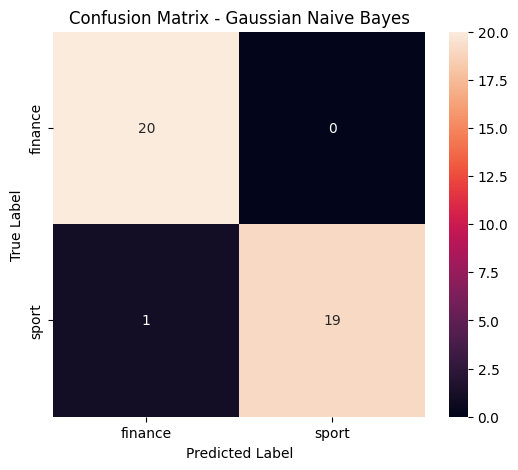

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["finance", "sport"],
    yticklabels=["finance", "sport"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

Kode tersebut digunakan untuk **menampilkan confusion matrix dalam bentuk heatmap** sebagai bagian dari evaluasi model Gaussian Naive Bayes. `plt.figure(figsize=(6, 5))` menentukan ukuran gambar, sedangkan `sns.heatmap()` digunakan untuk menampilkan nilai confusion matrix `cm` dalam bentuk tabel visual. Parameter `annot=True` menampilkan jumlah data pada setiap sel, sementara `fmt="d"` memastikan nilainya ditampilkan sebagai bilangan bulat. `xticklabels` menunjukkan label hasil prediksi dan `yticklabels` menunjukkan label sebenarnya, yaitu `finance` dan `sport`. Selanjutnya, `plt.xlabel()` dan `plt.ylabel()` memberikan keterangan pada masing-masing sumbu, sedangkan `plt.title()` memberikan judul grafik. Terakhir, `plt.show()` digunakan untuk menampilkan confusion matrix. Dengan visualisasi ini, dapat dilihat jumlah data yang **diprediksi benar maupun salah** pada masing-masing kelas.


In [35]:
hasil_evaluasi = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Nilai": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(hasil_evaluasi)

,Metrik,Nilai
0,Accuracy,0.975000
1,Precision,0.976190
2,Recall,0.975000
3,F1-Score,0.974984


In [36]:
hasil_preprocessing = df[[
    "id",
    "isi_berita",
    "label",
    "clean_text",
    "tokens_stopword",
    "tokens_stemmed"
]]

display(hasil_preprocessing.head(10))

,id,isi_berita,label,clean_text,tokens_stopword,tokens_stemmed
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,chef de mission cdm indonesia todotua pasaribu...,"[chef, de, mission, cdm, indonesia, todotua, p...","[chef, de, mission, cdm, indonesia, todotua, p..."
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,banjir besar melanda nagoya jepang menjelang a...,"[banjir, besar, melanda, nagoya, jepang, menje...","[banjir, besar, landa, nagoya, jepang, jelang,..."
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,ketua umum komite olimpiade indonesia koi raja...,"[ketua, umum, komite, olimpiade, indonesia, ko...","[ketua, umum, komite, olimpiade, indonesia, ko..."
3,4,Persaingan titel juara dunia semakin ketat men...,sport,persaingan titel juara dunia semakin ketat men...,"[persaingan, titel, juara, dunia, semakin, ket...","[saing, titel, juara, dunia, makin, ketat, tuj..."
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,sektor ganda campuran kembali mengalami peromb...,"[sektor, ganda, campuran, mengalami, perombaka...","[sektor, ganda, campur, alami, ombak, main, ka..."
5,6,"Pegokar muda Indonesia, Morgan Holindo, tak pu...",sport,pegokar muda indonesia morgan holindo tak puas...,"[pegokar, muda, indonesia, morgan, holindo, ta...","[gokar, muda, indonesia, morgan, holindo, tak,..."
6,7,Seri V Men's World Tennis Championship 2026 su...,sport,seri v mens world tennis championship sudah me...,"[seri, v, mens, world, tennis, championship, m...","[seri, v, mens, world, tennis, championship, p..."
7,8,Memperingati Hari Ulang Tahun (HUT) ke-81 TNI ...,sport,memperingati hari ulang tahun hut ke tni tahun...,"[memperingati, hari, ulang, tahun, hut, tni, t...","[ingat, hari, ulang, tahun, hut, tni, tahun, k..."
8,9,Pacuan kuda Indonesia mulai diarahkan menuju p...,sport,pacuan kuda indonesia mulai diarahkan menuju p...,"[pacuan, kuda, indonesia, mulai, diarahkan, me...","[pacu, kuda, indonesia, mulai, arah, tuju, pan..."
9,10,"Jelang Asian Games 2026, dukungan untuk 432 at...",sport,jelang asian games dukungan untuk atlet indone...,"[jelang, asian, games, dukungan, atlet, indone...","[jelang, asi, games, dukung, atlet, indonesia,..."


In [37]:
 hasil_export = df[[
     "id",
     "isi_berita",
     "label",
     "case_folding",
     "tanpa_tanda_baca",
     "tanpa_angka",
     "clean_text",
     "tokens_stopword",
     "tokens_stemmed"
 ]].copy()

 hasil_export["tokens_stopword"] = hasil_export["tokens_stopword"].apply(
     lambda x: " ".join(x)
 )

 hasil_export["tokens_stemmed"] = hasil_export["tokens_stemmed"].apply(
     lambda x: " ".join(x)
 )

 hasil_export.to_excel(
     "hasil_preprocessing.xlsx",
     index=False
 )

 print("File berhasil disimpan sebagai:")
 print("hasil_preprocessing.xlsx")

File berhasil disimpan sebagai:
hasil_preprocessing.xlsx
